# Midterm Exam - Model A - Matthew Shaver

## Setup

In [16]:
from pathlib import Path
import importlib
import json
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from PIL import Image
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)

print('PyTorch version:', torch.__version__)

PyTorch version: 2.11.0+cu128


In [17]:
GITHUB_REPO_URL = 'https://github.com/shaverm96/DSBA-6165-Sum-2026-Take-Home-Exam.git'
COLAB_REPO_DIR = Path('/content/Applied-AI-Midterm')
COLAB_DRIVE_DIR = Path('/content/drive/MyDrive/Applied-AI-Midterm')
SEED = 42
IMAGE_SIZE = 128
BATCH_SIZE = 32
CLASS_NAMES = ('cats', 'dogs')

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)

    if (COLAB_REPO_DIR / '.git').exists():
        pull_result = subprocess.run(
            ['git', 'pull', '--ff-only', 'origin', 'main'],
            cwd=COLAB_REPO_DIR,
            capture_output=True,
            text=True,
        )
        if pull_result.returncode != 0:
            raise RuntimeError(pull_result.stderr.strip())
        print(pull_result.stdout.strip() or 'Repository is already up to date.')
    else:
        clone_result = subprocess.run(
            ['git', 'clone', GITHUB_REPO_URL, str(COLAB_REPO_DIR)],
            capture_output=True,
            text=True,
        )
        if clone_result.returncode != 0:
            raise RuntimeError(clone_result.stderr.strip())
        print('Repository cloned into Colab.')

    PROJECT_ROOT = COLAB_REPO_DIR
    ARTIFACT_ROOT = COLAB_DRIVE_DIR
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / 'configs').exists() and (PROJECT_ROOT.parent / 'configs').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    ARTIFACT_ROOT = PROJECT_ROOT

print('Project root:', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
Project root: /content/Applied-AI-Midterm


In [18]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'config.yaml'
with CONFIG_PATH.open('r', encoding='utf-8') as file:
    CONFIG = yaml.safe_load(file)

IMAGE_SIZE = int(CONFIG['training']['image_size'])
BATCH_SIZE = int(CONFIG['training']['batch_size'])
NUM_WORKERS = 0 if IN_COLAB else int(CONFIG['training']['num_workers'])
CLASS_NAMES = tuple(CONFIG['dataset']['classes'])
CHECKPOINT_DIR = ARTIFACT_ROOT / CONFIG['paths']['model_dir']
OUTPUT_DIR = ARTIFACT_ROOT / CONFIG['paths']['output_dir'] / 'model_a'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import src.data.dataset as dataset_module
from src.data.transforms import IMAGENET_MEAN, IMAGENET_STD, get_classifier_transforms
from src.models.classifier import ResNet18Classifier
import src.training.train_classifier as train_classifier_module
from src.utils.device import get_device
from src.utils.reproducibility import set_seed

importlib.reload(dataset_module)
importlib.reload(train_classifier_module)
ImageClassificationDataset = dataset_module.ImageClassificationDataset
build_classification_loaders = train_classifier_module.build_classification_loaders
train_classifier = train_classifier_module.train_classifier

set_seed(SEED)
DEVICE = get_device()

print('Image size:', IMAGE_SIZE)
print('Batch size:', BATCH_SIZE)
print('DataLoader workers:', NUM_WORKERS)
print('Classes:', CLASS_NAMES)
print('Checkpoint directory:', CHECKPOINT_DIR)
print('Device:', DEVICE)

Image size: 128
Batch size: 32
DataLoader workers: 0
Classes: ('cats', 'dogs')
Checkpoint directory: /content/drive/MyDrive/Applied-AI-Midterm/models/checkpoints
Device: cuda


In [ ]:
PHASE_NAMES = ('model_a_frozen', 'model_a')
LOCAL_CHECKPOINT_DIR = PROJECT_ROOT / CONFIG['paths']['model_dir']


def quarantine_checkpoint(checkpoint_dir):
    quarantine_root = CHECKPOINT_DIR / 'invalid_split'
    quarantine_root.mkdir(parents=True, exist_ok=True)
    destination = quarantine_root / checkpoint_dir.name
    copy_number = 1
    while destination.exists():
        destination = quarantine_root / f'{checkpoint_dir.name}_{copy_number}'
        copy_number += 1
    shutil.move(str(checkpoint_dir), str(destination))
    print('Moved incompatible checkpoint to:', destination)


if IN_COLAB and LOCAL_CHECKPOINT_DIR != CHECKPOINT_DIR:
    for phase_name in PHASE_NAMES:
        local_phase_dir = LOCAL_CHECKPOINT_DIR / phase_name
        drive_phase_dir = CHECKPOINT_DIR / phase_name
        if local_phase_dir.exists() and not drive_phase_dir.exists():
            shutil.copytree(local_phase_dir, drive_phase_dir)
            print('Copied old checkpoint to Drive:', drive_phase_dir)

for phase_name in PHASE_NAMES:
    phase_dir = CHECKPOINT_DIR / phase_name
    print(
        phase_name,
        '| last:', (phase_dir / 'last.pt').exists(),
        '| best:', (phase_dir / 'best.pt').exists(),
        '| history:', (phase_dir / 'history.json').exists(),
    )

model_a_frozen | last: True | best: True | history: False
model_a | last: True | best: True | history: False


## Dataset

In [ ]:
TRAINING_CONFIG = CONFIG['training']
CLASSIFIER_CONFIG = CONFIG['model']['classifier']
SPLIT_DIR = PROJECT_ROOT / CONFIG['paths']['splits_dir']

train_table = pd.read_csv(SPLIT_DIR / 'train_split.csv')
val_table = pd.read_csv(SPLIT_DIR / 'val_split.csv')
test_table = pd.read_csv(SPLIT_DIR / 'test_split.csv')
split_tables = {
    'training': train_table,
    'validation': val_table,
    'test': test_table,
}

expected_classes = set(CLASS_NAMES)
SPLIT_METADATA = {}
for split_name, split_table in split_tables.items():
    class_counts = split_table['label'].value_counts().sort_index()
    observed_classes = set(class_counts.index)
    if observed_classes != expected_classes:
        raise ValueError(
            f'{split_name.title()} split must contain {sorted(expected_classes)}; '
            f'found {sorted(observed_classes)}. Rerun the data exploration notebook.'
        )
    SPLIT_METADATA[split_name] = {
        class_name: int(class_counts.get(class_name, 0))
        for class_name in CLASS_NAMES
    }
    print(f'{split_name.title()} images:', len(split_table))
    print(class_counts)

train_loader, val_loader = build_classification_loaders(
    split_dir=SPLIT_DIR,
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

batch_images, batch_labels, batch_paths = next(iter(train_loader))
print('Training batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Batch image shape:', tuple(batch_images.shape))
print('Batch label shape:', tuple(batch_labels.shape))

Training images: 257
label
cats    257
Name: count, dtype: int64
Validation images: 46
label
cats    46
Name: count, dtype: int64
Test images: 130
label
cats    130
Name: count, dtype: int64
Training batches: 9
Validation batches: 2
Batch image shape: (32, 3, 128, 128)
Batch label shape: (32,)


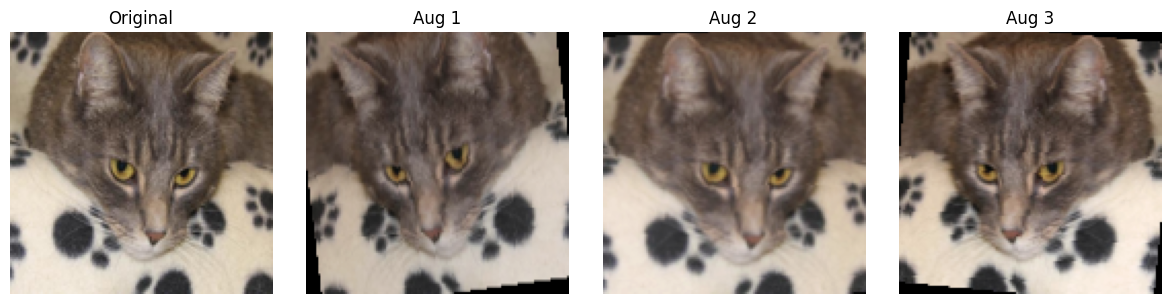

In [21]:
transform_map = get_classifier_transforms(image_size=IMAGE_SIZE)
sample_path = batch_paths[0]
sample_image = Image.open(sample_path).convert('RGB')
original_image = sample_image.resize((IMAGE_SIZE, IMAGE_SIZE))
augmented_tensors = [transform_map['train'](sample_image) for _ in range(3)]

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
augmented_images = [
    torch.clamp(image * std + mean, 0, 1).permute(1, 2, 0)
    for image in augmented_tensors
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(original_image)
axes[0].set_title('Original')
axes[0].axis('off')

for ax, image, title in zip(axes[1:], augmented_images, ['Aug 1', 'Aug 2', 'Aug 3']):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## ResNet18 baseline

Use a frozen pretrained backbone first.

In [ ]:
model = ResNet18Classifier(
    pretrained=bool(CLASSIFIER_CONFIG['pretrained']),
    dropout=float(CLASSIFIER_CONFIG['classifier_dropout']),
)
model.freeze_backbone()



ResNet18Classifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [ ]:
FROZEN_EPOCHS = 15
FROZEN_CHECKPOINT_DIR = CHECKPOINT_DIR / 'model_a_frozen'
frozen_resume = FROZEN_CHECKPOINT_DIR / 'last.pt'
frozen_metadata_path = FROZEN_CHECKPOINT_DIR / 'split_metadata.json'

saved_split_metadata = None
if frozen_metadata_path.exists():
    saved_split_metadata = json.loads(frozen_metadata_path.read_text(encoding='utf-8'))
has_frozen_checkpoints = FROZEN_CHECKPOINT_DIR.exists() and any(
    FROZEN_CHECKPOINT_DIR.glob('*.pt')
)
if has_frozen_checkpoints and saved_split_metadata != SPLIT_METADATA:
    quarantine_checkpoint(FROZEN_CHECKPOINT_DIR)
    frozen_resume = None
elif not frozen_resume.exists():
    frozen_resume = None

FROZEN_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
frozen_metadata_path.write_text(
    json.dumps(SPLIT_METADATA, indent=2),
    encoding='utf-8',
)

history = train_classifier(
    model=model,
    train_loader=train_loader,
    validation_loader=val_loader,
    device=DEVICE,
    epochs=FROZEN_EPOCHS,
    learning_rate=float(CLASSIFIER_CONFIG['learning_rate']),
    weight_decay=float(CLASSIFIER_CONFIG['weight_decay']),
    patience=int(TRAINING_CONFIG['early_stopping_patience']),
    checkpoint_dir=FROZEN_CHECKPOINT_DIR,
    resume_from=frozen_resume,
    freeze_backbone_epochs=FROZEN_EPOCHS,
)

pd.DataFrame(history)

,epoch,learning_rate,epoch_seconds,train_accuracy,train_precision,train_recall,train_f1,train_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_loss
0,1.0,0.0001,3.047384,0.420233,0.0,0.0,0.0,0.804079,0.630435,0.0,0.0,0.0,0.675614
1,2.0,0.0001,1.637296,0.677043,0.0,0.0,0.0,0.604473,0.847826,0.0,0.0,0.0,0.461131
2,3.0,0.0001,1.599164,0.844358,0.0,0.0,0.0,0.474287,0.934783,0.0,0.0,0.0,0.322571
3,4.0,0.0001,1.574568,0.929961,0.0,0.0,0.0,0.349276,0.978261,0.0,0.0,0.0,0.233719
4,5.0,0.0001,1.590927,0.988327,0.0,0.0,0.0,0.284525,1.000000,0.0,0.0,0.0,0.150949
5,6.0,0.0001,1.584535,0.996109,0.0,0.0,0.0,0.218626,1.000000,0.0,0.0,0.0,0.114609
6,7.0,0.0001,1.585573,0.988327,0.0,0.0,0.0,0.186709,1.000000,0.0,0.0,0.0,0.088703
7,8.0,0.0001,1.646434,0.996109,0.0,0.0,0.0,0.155568,1.000000,0.0,0.0,0.0,0.077303
8,9.0,0.0001,1.633869,0.996109,0.0,0.0,0.0,0.131336,1.000000,0.0,0.0,0.0,0.065798
9,10.0,0.0001,1.596200,1.000000,0.0,0.0,0.0,0.123671,1.000000,0.0,0.0,0.0,0.054153


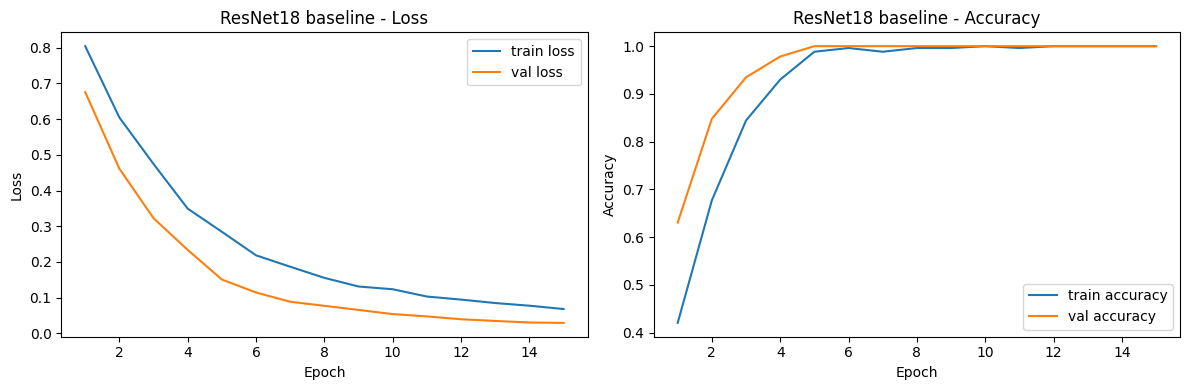

In [24]:
def plot_learning(history, title, output_path=None):
    metrics = pd.DataFrame(history)
    epochs = metrics['epoch']

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['train_loss'], label='train loss')
    plt.plot(epochs, metrics['validation_loss'], label='val loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['train_accuracy'], label='train accuracy')
    plt.plot(epochs, metrics['validation_accuracy'], label='val accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()


plot_learning(history, 'ResNet18 baseline')

## Fine-tune ResNet18

Unfreeze the backbone and train again with a smaller learning rate.

In [ ]:
model.unfreeze_backbone()

FINE_TUNE_EPOCHS = max(int(TRAINING_CONFIG['classifier_epochs']) - FROZEN_EPOCHS, 1)
FINE_TUNE_CHECKPOINT_DIR = CHECKPOINT_DIR / 'model_a'
fine_tune_resume = FINE_TUNE_CHECKPOINT_DIR / 'last.pt'
fine_tune_metadata_path = FINE_TUNE_CHECKPOINT_DIR / 'split_metadata.json'

saved_split_metadata = None
if fine_tune_metadata_path.exists():
    saved_split_metadata = json.loads(fine_tune_metadata_path.read_text(encoding='utf-8'))
has_fine_tune_checkpoints = FINE_TUNE_CHECKPOINT_DIR.exists() and any(
    FINE_TUNE_CHECKPOINT_DIR.glob('*.pt')
)
if has_fine_tune_checkpoints and saved_split_metadata != SPLIT_METADATA:
    quarantine_checkpoint(FINE_TUNE_CHECKPOINT_DIR)
    fine_tune_resume = None
elif not fine_tune_resume.exists():
    fine_tune_resume = None

FINE_TUNE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
fine_tune_metadata_path.write_text(
    json.dumps(SPLIT_METADATA, indent=2),
    encoding='utf-8',
)

TRAINABLE_PARAMETERS = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print('Trainable parameters:', TRAINABLE_PARAMETERS)
print('Learning rate:', float(CLASSIFIER_CONFIG['learning_rate']) / 10)
print('Resume checkpoint:', fine_tune_resume)

Trainable parameters: 11177025
Learning rate: 1e-05
Resume checkpoint: /content/drive/MyDrive/Applied-AI-Midterm/models/checkpoints/model_a/last.pt


In [26]:
history = train_classifier(
    model=model,
    train_loader=train_loader,
    validation_loader=val_loader,
    device=DEVICE,
    epochs=FINE_TUNE_EPOCHS,
    learning_rate=float(CLASSIFIER_CONFIG['learning_rate']) / 10,
    weight_decay=float(CLASSIFIER_CONFIG['weight_decay']),
    patience=int(TRAINING_CONFIG['early_stopping_patience']),
    checkpoint_dir=FINE_TUNE_CHECKPOINT_DIR,
    resume_from=fine_tune_resume,
    freeze_backbone_epochs=0,
)

pd.DataFrame(history).tail()

,epoch,learning_rate,epoch_seconds,train_accuracy,train_precision,train_recall,train_f1,train_loss,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_loss
10,11.0,0.00001,1.675731,1.0,0.0,0.0,0.0,0.034080,1.0,0.0,0.0,0.0,0.024447
11,12.0,0.00001,1.621506,1.0,0.0,0.0,0.0,0.032995,1.0,0.0,0.0,0.0,0.022950
12,13.0,0.00001,1.634401,1.0,0.0,0.0,0.0,0.031070,1.0,0.0,0.0,0.0,0.022419
13,14.0,0.00001,1.641886,1.0,0.0,0.0,0.0,0.029780,1.0,0.0,0.0,0.0,0.021193
14,15.0,0.00001,1.634896,1.0,0.0,0.0,0.0,0.029776,1.0,0.0,0.0,0.0,0.019649


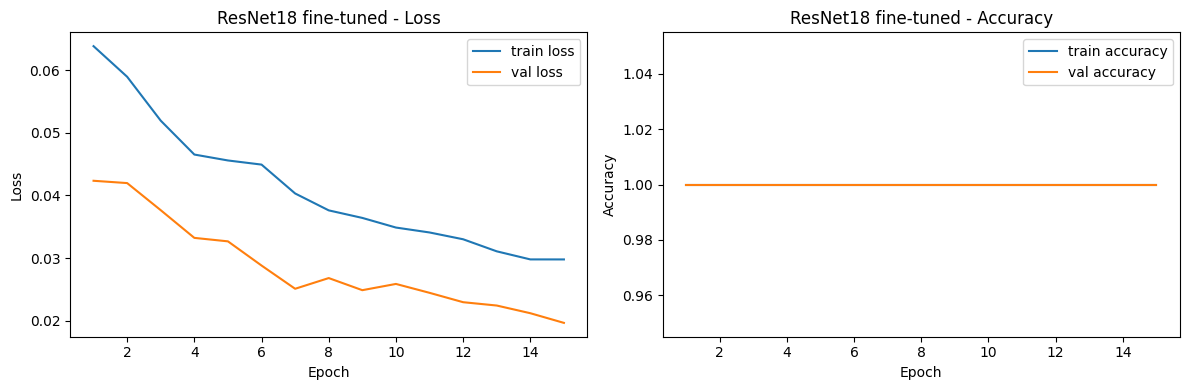

Training history saved to: /content/drive/MyDrive/Applied-AI-Midterm/outputs/model_a/training_history.png


In [27]:
plot_learning(
    history,
    'ResNet18 fine-tuned',
    OUTPUT_DIR / 'training_history.png',
)

print('Training history saved to:', OUTPUT_DIR / 'training_history.png')

## Test Model A

Load the best fine-tuned checkpoint and evaluate the untouched test data.

In [ ]:
BEST_MODEL_PATH = FINE_TUNE_CHECKPOINT_DIR / 'best.pt'
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError('Complete Model A training before running the test evaluation.')
if not fine_tune_metadata_path.exists():
    raise RuntimeError('Checkpoint metadata is missing. Rerun Model A training with the valid splits.')
saved_split_metadata = json.loads(fine_tune_metadata_path.read_text(encoding='utf-8'))
if saved_split_metadata != SPLIT_METADATA:
    raise RuntimeError('Checkpoint data does not match the current splits. Rerun Model A training.')

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()

test_dataset = ImageClassificationDataset(
    split_csv=SPLIT_DIR / 'test_split.csv',
    class_names=CLASS_NAMES,
    transform=get_classifier_transforms(image_size=IMAGE_SIZE)['test'],
    validate_images=True,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == 'cuda',
)

valid_test_classes = set(test_dataset.records['label'])
if valid_test_classes != expected_classes:
    raise ValueError(
        f'Valid test images must contain {sorted(expected_classes)}; '
        f'found {sorted(valid_test_classes)}. Rerun the data exploration notebook.'
    )

print('Loaded model:', BEST_MODEL_PATH)
print('Test images:', len(test_dataset))
print('Test batches:', len(test_loader))
print('Skipped invalid test images:', len(test_dataset.invalid_image_paths))
for invalid_path in test_dataset.invalid_image_paths:
    print('Skipped:', Path(invalid_path).name)

Loaded model: /content/drive/MyDrive/Applied-AI-Midterm/models/checkpoints/model_a/best.pt
Test images: 129
Test batches: 5
Skipped invalid test images: 1
Skipped: cat_test_01246.jpg


In [ ]:
all_probabilities = []
all_targets = []
all_paths = []

with torch.inference_mode():
    for images, labels, image_paths in test_loader:
        logits = model(images.to(DEVICE, non_blocking=DEVICE.type == 'cuda'))
        all_probabilities.append(torch.sigmoid(logits).cpu())
        all_targets.append(labels.cpu())
        all_paths.extend(image_paths)

probabilities = torch.cat(all_probabilities).numpy()
targets = torch.cat(all_targets).numpy().astype(int)
predictions = (probabilities >= 0.5).astype(int)

expected_target_indices = {0, 1}
observed_target_indices = set(targets.tolist())
if observed_target_indices != expected_target_indices:
    raise ValueError(
        f'Evaluation requires target indices {sorted(expected_target_indices)}; '
        f'found {sorted(observed_target_indices)}.'
    )

target_counts = pd.Series(targets).value_counts().reindex([0, 1], fill_value=0)
prediction_counts = pd.Series(predictions).value_counts().reindex([0, 1], fill_value=0)
print('Target counts:', {CLASS_NAMES[index]: int(target_counts[index]) for index in [0, 1]})
print('Prediction counts:', {CLASS_NAMES[index]: int(prediction_counts[index]) for index in [0, 1]})

false_positive_rate, true_positive_rate, _ = roc_curve(targets, probabilities)
test_metrics = {
    'accuracy': float(accuracy_score(targets, predictions)),
    'precision': float(precision_score(targets, predictions, zero_division=0)),
    'recall': float(recall_score(targets, predictions, zero_division=0)),
    'f1': float(f1_score(targets, predictions, zero_division=0)),
    'roc_auc': float(auc(false_positive_rate, true_positive_rate)),
}

print(pd.Series(test_metrics).round(4))

accuracy     1.0
precision    0.0
recall       0.0
f1           0.0
roc_auc      NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


ValueError: The number of FixedLocator locations (1), usually from a call to set_ticks, does not match the number of labels (2).

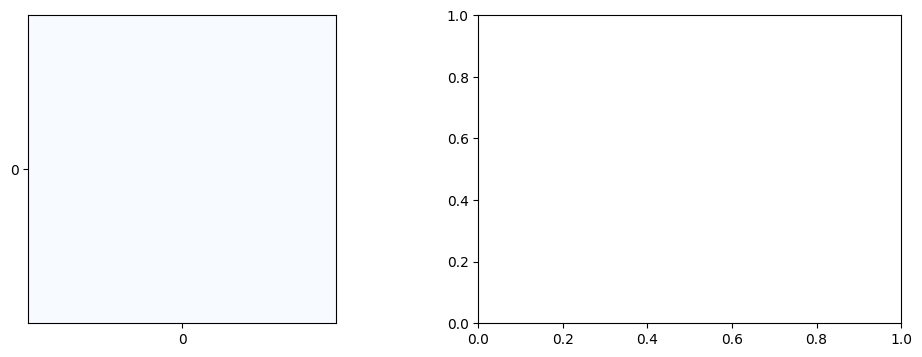

In [ ]:
prediction_table = pd.DataFrame({
    'image_path': all_paths,
    'actual': [CLASS_NAMES[index] for index in targets],
    'probability_dog': probabilities,
    'predicted': [CLASS_NAMES[index] for index in predictions],
})

(OUTPUT_DIR / 'test_metrics.json').write_text(
    json.dumps(test_metrics, indent=2),
    encoding='utf-8',
)
prediction_table.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(
    confusion_matrix(targets, predictions, labels=[0, 1]),
    display_labels=CLASS_NAMES,
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Model A - Confusion Matrix')

axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC = {test_metrics['roc_auc']:.3f}",
)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('Model A - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_evaluation.png', dpi=200, bbox_inches='tight')
plt.show()

print('Results saved to:', OUTPUT_DIR)

## Results

The test metrics, predictions, learning curve, confusion matrix, and ROC curve are saved in the Model A output folder.

## Checkpoints

In Colab, `last.pt`, `best.pt`, and `history.json` are saved in Google Drive after every epoch. Rerunning the training cells resumes from `last.pt`.